In [1]:
# Jupyter: 커널 → 재시작 및 모든 출력 지우기 후 실행
import tensorflow as tf
print("TF:", tf.__version__)   # 2.18.0

import keras
print("Keras:", keras.__version__)   # 3.x

TF: 2.21.0
Keras: 3.13.2


In [2]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'   # keras 호환 플래그 (맨 위에)

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Input, Dropout, Conv1DTranspose
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)   # 2.18.0 출력되면 정상

TensorFlow: 2.18.0


In [3]:
dir(pd)

['ArrowDtype',
 'BooleanDtype',
 'Categorical',
 'CategoricalDtype',
 'CategoricalIndex',
 'DataFrame',
 'DateOffset',
 'DatetimeIndex',
 'DatetimeTZDtype',
 'ExcelFile',
 'ExcelWriter',
 'Flags',
 'Float32Dtype',
 'Float64Dtype',
 'Grouper',
 'HDFStore',
 'Index',
 'IndexSlice',
 'Int16Dtype',
 'Int32Dtype',
 'Int64Dtype',
 'Int8Dtype',
 'Interval',
 'IntervalDtype',
 'IntervalIndex',
 'MultiIndex',
 'NA',
 'NaT',
 'NamedAgg',
 'Period',
 'PeriodDtype',
 'PeriodIndex',
 'RangeIndex',
 'Series',
 'SparseDtype',
 'StringDtype',
 'Timedelta',
 'TimedeltaIndex',
 'Timestamp',
 'UInt16Dtype',
 'UInt32Dtype',
 'UInt64Dtype',
 'UInt8Dtype',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__docformat__',
 '__file__',
 '__git_version__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_built_with_meson',
 '_config',
 '_is_numpy_dev',
 '_libs',
 '_pandas_datetime_CAPI',
 '_pandas_parser_CAPI',
 '_testing',
 '_typing',
 '_version_meson',
 'annota

In [4]:
vib_normal_ds = pd.read_csv("data/vibration_normal.csv")
vib_normal_ds.head()

,Time,0,3.12,6.25,9.38,12.5,15.62,18.75,21.88,25,...,1568.75,1571.88,1575,1578.12,1581.25,1584.38,1587.5,1590.62,1593.75,1596.88
0,2021-08-02 6:47,0.000448,0.000634,0.000895,0.001124,0.000333,0.000583,0.000242,0.000743,0.001193,...,0.000317,0.000457,0.000994,0.000815,0.000344,0.000280,0.000636,0.000639,0.000780,0.000728
1,2021-08-02 7:12,0.000001,0.000176,0.000315,0.000793,0.001073,0.001130,0.001330,0.000867,0.000609,...,0.000352,0.000346,0.000111,0.000173,0.000533,0.000419,0.000422,0.000654,0.000172,0.000238
2,2021-08-02 7:36,0.000594,0.000379,0.001343,0.000454,0.000517,0.000454,0.000693,0.001282,0.001232,...,0.000143,0.000389,0.000983,0.000983,0.000157,0.000881,0.001318,0.000757,0.000638,0.000872
3,2021-08-02 7:59,0.000168,0.000438,0.000732,0.000812,0.000957,0.000835,0.001051,0.000489,0.000181,...,0.000894,0.000802,0.000983,0.000872,0.000740,0.000222,0.000566,0.000917,0.000849,0.000489
4,2021-08-02 8:27,0.000370,0.000512,0.000656,0.000267,0.000236,0.000236,0.000305,0.000629,0.001426,...,0.000731,0.000453,0.000630,0.000712,0.000496,0.000706,0.000513,0.000119,0.000599,0.000746


In [5]:
vib_anomaly_ds = pd.read_csv("data/vibration_anomaly.csv")
vib_anomaly_ds.head()

,Time,0,3.12,6.25,9.38,12.5,15.62,18.75,21.88,25,...,1568.75,1571.88,1575,1578.12,1581.25,1584.38,1587.5,1590.62,1593.75,1596.88
0,2022-01-17 16:53,0.017119,0.031108,0.018228,0.045243,0.032953,0.011007,0.020632,0.022722,0.021065,...,0.003080,0.047822,0.073223,0.029722,0.016643,0.005442,0.044247,0.033641,0.034237,0.047196
1,2022-01-26 14:50,0.008463,0.020489,0.040288,0.011786,0.006749,0.027902,0.036479,0.016292,0.009036,...,0.014840,0.025090,0.025218,0.018054,0.023980,0.018671,0.013548,0.043027,0.054982,0.034446
2,2022-02-10 18:16,0.013359,0.049131,0.076610,0.061570,0.055249,0.043330,0.030105,0.028493,0.044670,...,0.052756,0.061957,0.036153,0.027028,0.055728,0.057243,0.039780,0.034525,0.041085,0.023809
3,2022-02-22 9:21,0.016137,0.034178,0.022711,0.036808,0.054250,0.031692,0.011437,0.006979,0.010247,...,0.009296,0.003761,0.002089,0.007499,0.007337,0.004411,0.001132,0.004809,0.004792,0.006091
4,2022-02-23 19:40,0.002293,0.031036,0.061567,0.057566,0.040840,0.025495,0.012431,0.010275,0.011133,...,0.023630,0.017060,0.008875,0.005707,0.006139,0.007393,0.002851,0.006780,0.009328,0.006557


In [6]:
cur_normal_ds = pd.read_csv("data/current_normal.csv")
cur_normal_ds.head()

,Time,0,1.91,3.81,5.72,7.63,9.54,11.44,13.35,15.26,...,1933.93,1935.83,1937.74,1939.65,1941.56,1943.46,1945.37,1947.28,1949.19,1951.09
0,2021-09-01 0:04,0.028044,0.033194,0.023135,0.019984,0.012384,0.015154,0.003928,0.002710,0.001608,...,0.000641,0.000434,0.000695,0.000511,0.000566,0.000929,0.000841,0.000147,0.000633,0.000309
1,2021-09-01 0:07,0.017024,0.061488,0.025492,0.019490,0.003985,0.000198,0.001219,0.000958,0.000525,...,0.000394,0.000437,0.000833,0.001000,0.001070,0.000533,0.000425,0.000545,0.000734,0.000580
2,2021-09-01 0:10,0.055605,0.051026,0.033430,0.015864,0.010201,0.004803,0.001797,0.002638,0.002295,...,0.000610,0.000373,0.000331,0.000151,0.000219,0.000310,0.000346,0.000757,0.000883,0.000536
3,2021-09-01 0:17,0.070640,0.090214,0.061381,0.023377,0.018212,0.004499,0.001965,0.002304,0.002807,...,0.000676,0.000503,0.000430,0.000347,0.000463,0.000607,0.000992,0.000579,0.000623,0.000383
4,2021-09-01 0:21,0.089390,0.101223,0.069492,0.029898,0.013571,0.007979,0.002882,0.003186,0.000395,...,0.000552,0.000507,0.000512,0.000557,0.000603,0.000919,0.000860,0.000146,0.000602,0.000272


In [7]:
cur_anomaly_ds = pd.read_csv("data/current_anomaly.csv")
cur_anomaly_ds.head()

,Time,0,1.91,3.81,5.72,7.63,9.54,11.44,13.35,15.26,...,1933.93,1935.83,1937.74,1939.65,1941.56,1943.46,1945.37,1947.28,1949.19,1951.09
0,2021-07-21 15:40,3.767835,4.020009,0.875950,6.156515,5.546138,3.100119,8.766246,1.633168,5.111375,...,0.088311,0.132539,0.089407,0.099254,0.234076,0.155161,0.215416,0.254271,0.246627,0.147443
1,2021-07-21 16:33,5.106608,12.013001,9.308904,5.215157,10.490317,2.403275,14.367259,14.665602,4.620723,...,0.304766,0.085849,0.090350,0.131499,0.067617,0.171688,0.103295,0.112468,0.171594,0.108564
2,2021-07-21 19:58,5.747002,12.725037,10.936867,5.417918,6.302464,6.878624,6.669328,6.745722,6.463291,...,0.407950,0.380353,0.376850,0.331752,0.184041,0.163163,0.248755,0.190100,0.068477,0.089433
3,2021-07-22 13:19,6.930827,9.550858,12.423865,5.608191,4.370304,2.212492,2.340739,2.469330,6.216851,...,0.085864,0.120988,0.185122,0.075912,0.097762,0.065786,0.023454,0.141953,0.200623,0.054378
4,2021-07-22 13:25,2.577766,8.017437,5.942433,8.286139,6.780290,5.479986,5.983894,6.516971,5.466931,...,0.197637,0.298523,0.180578,0.121295,0.091325,0.079708,0.164527,0.270300,0.144208,0.174007


In [8]:
vib_normal_ds.tail()

,Time,0,3.12,6.25,9.38,12.5,15.62,18.75,21.88,25,...,1568.75,1571.88,1575,1578.12,1581.25,1584.38,1587.5,1590.62,1593.75,1596.88
1769,2021-08-31 22:20,0.000503,0.000388,0.000651,0.000521,0.000973,0.002019,0.001346,0.000315,0.000924,...,0.000676,0.000622,0.000238,0.000232,0.000432,0.000048,0.000363,0.000365,0.000355,0.000165
1770,2021-08-31 22:42,0.000093,0.000422,0.000299,0.000817,0.001066,0.001203,0.000519,0.000725,0.000528,...,0.000588,0.000389,0.000381,0.000345,0.000168,0.000359,0.000824,0.000444,0.000590,0.000481
1771,2021-08-31 23:05,0.000463,0.000883,0.000427,0.000309,0.000452,0.000650,0.000426,0.000409,0.000721,...,0.000286,0.000756,0.000955,0.000432,0.000063,0.000381,0.000736,0.000550,0.000121,0.000194
1772,2021-08-31 23:30,0.000801,0.000405,0.000888,0.000301,0.000472,0.000905,0.001508,0.001134,0.000411,...,0.000033,0.000481,0.000265,0.000118,0.000394,0.000222,0.000259,0.000514,0.000844,0.000354
1773,2021-08-31 23:54,0.000278,0.000231,0.000284,0.000211,0.000166,0.000481,0.000161,0.000512,0.000342,...,0.000640,0.000910,0.000391,0.000152,0.000071,0.000193,0.000626,0.000571,0.000371,0.000330


In [9]:
vib_normal_ds[15:20]

,Time,0,3.12,6.25,9.38,12.5,15.62,18.75,21.88,25,...,1568.75,1571.88,1575,1578.12,1581.25,1584.38,1587.5,1590.62,1593.75,1596.88
15,2021-08-02 12:54,0.000003,0.000337,0.000265,0.000236,0.001124,0.000280,0.001014,0.000994,0.000305,...,0.000634,0.000388,0.000599,0.000563,0.000982,0.001630,0.001289,0.000433,0.000642,0.000484
16,2021-08-02 13:16,0.000006,0.000227,0.000423,0.000196,0.000499,0.000243,0.000404,0.000088,0.000253,...,0.000288,0.000307,0.000515,0.000528,0.000308,0.000156,0.000821,0.000906,0.000727,0.000538
17,2021-08-02 13:45,0.000092,0.000120,0.000218,0.000791,0.001078,0.000269,0.000898,0.001300,0.001154,...,0.001592,0.001099,0.000414,0.000096,0.001305,0.001374,0.001582,0.002135,0.001181,0.000277
18,2021-08-02 14:07,0.000548,0.000253,0.000721,0.000092,0.000242,0.000736,0.000756,0.001015,0.001805,...,0.000854,0.001059,0.000213,0.001331,0.001270,0.000835,0.000823,0.000115,0.000797,0.000341
19,2021-08-02 14:32,0.000431,0.000776,0.000525,0.000803,0.000776,0.000740,0.001121,0.001203,0.001161,...,0.000724,0.000545,0.000709,0.000306,0.000518,0.000988,0.000814,0.000556,0.000966,0.001070


In [10]:
# 시각화 공통 속성 지정. rc(runtime configuration)
plt.rc("font", size=20)
plt.rc("axes", labelsize=20)
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.rc("legend", fontsize=20)
plt.rc("figure", titlesize=30)

<function matplotlib.pyplot.show(close=None, block=None)>

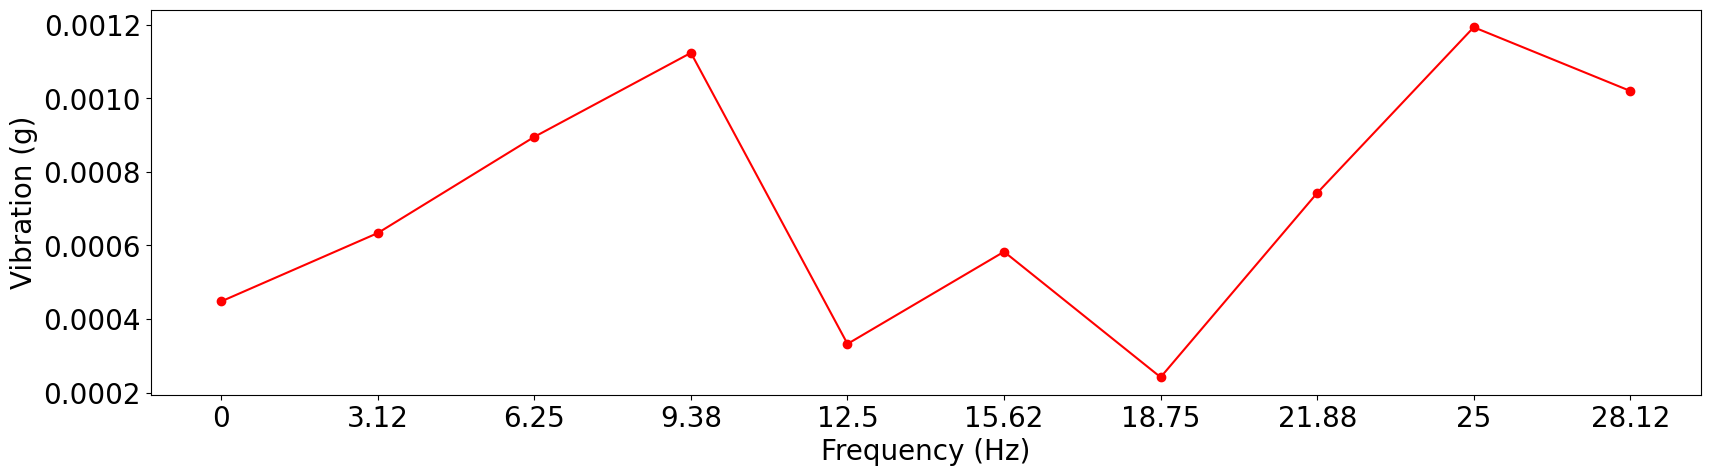

In [11]:
plt.figure(figsize=(20, 5))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Vibration (g)")
plt.plot(vib_normal_ds.iloc[0, 1:11], marker="o", color="red") # makrer: o, *, +  | color : red, blue, green 
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

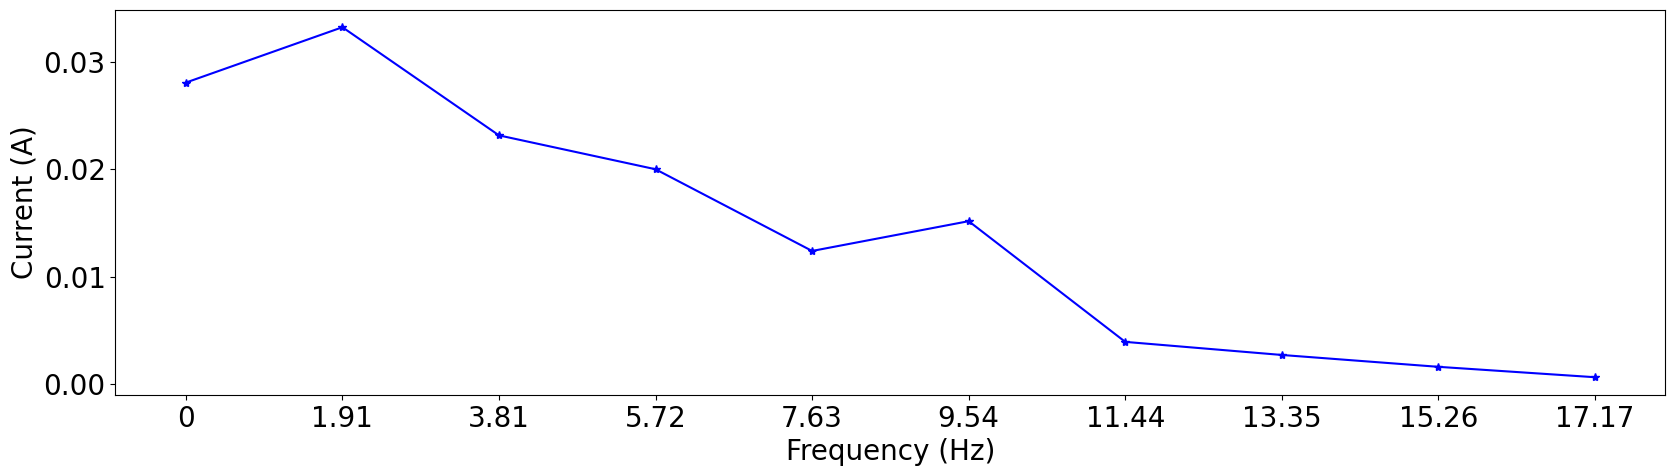

In [12]:
plt.figure(figsize=(20, 5))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Current (A)")
plt.plot(cur_normal_ds.iloc[0, 1:11], marker="*", color="blue")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

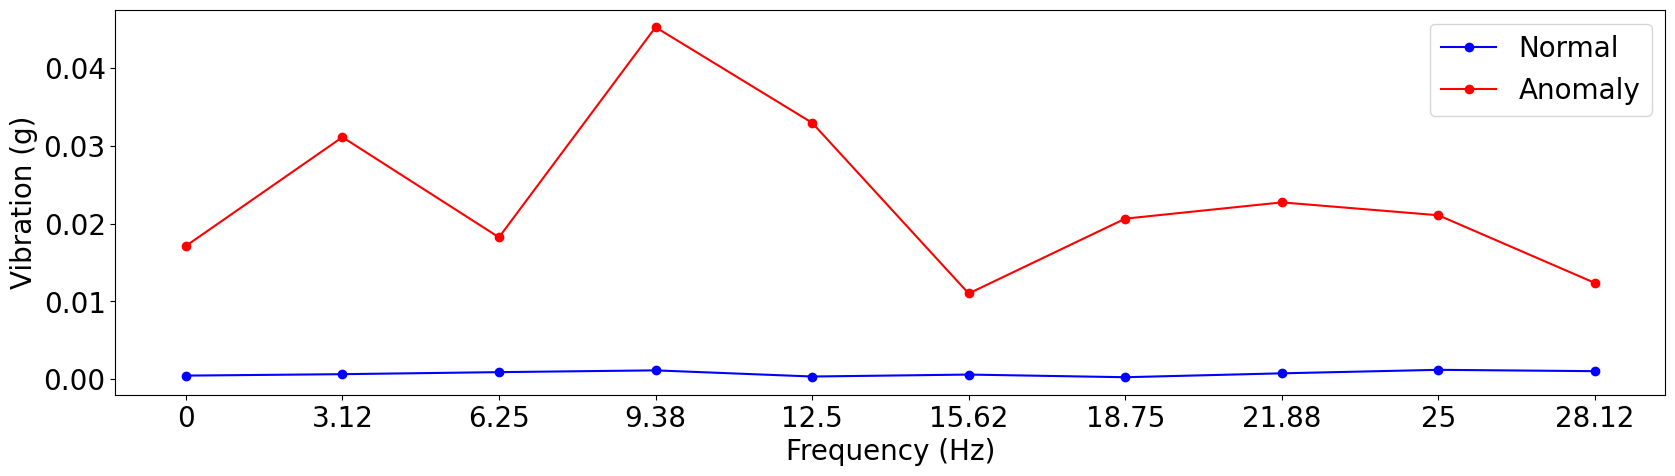

In [13]:
plt.figure(figsize=(20, 5))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Vibration (g)")
plt.plot(vib_normal_ds.iloc[0, 1:11], marker="o", color="blue", label="Normal") # makrer: o, *, +  | color : red, blue, green 
plt.plot(vib_anomaly_ds.iloc[0, 1:11], marker="o", color="red", label="Anomaly") # makrer: o, *, +  | color : red, blue, green 
plt.legend()
plt.show

In [14]:
vib_normal_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 1774 entries, 0 to 1773
Columns: 513 entries, Time to 1596.88
dtypes: float64(512), str(1)
memory usage: 6.9 MB


In [15]:
vib_anomaly_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Columns: 513 entries, Time to 1596.88
dtypes: float64(512), str(1)
memory usage: 64.3 KB


In [16]:
cur_normal_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 8202 entries, 0 to 8201
Columns: 1025 entries, Time to 1951.09
dtypes: float64(1024), str(1)
memory usage: 64.1 MB


In [17]:
cur_anomaly_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Columns: 1025 entries, Time to 1951.09
dtypes: float64(1024), str(1)
memory usage: 256.4 KB


In [18]:
vib_normal_ds.describe()

,0,3.12,6.25,9.38,12.5,15.62,18.75,21.88,25,28.12,...,1568.75,1571.88,1575,1578.12,1581.25,1584.38,1587.5,1590.62,1593.75,1596.88
count,1.774000e+03,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,...,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000
mean,3.957833e-04,0.000739,0.000791,0.000755,0.000792,0.000819,0.000837,0.000875,0.000904,0.000923,...,0.000628,0.000628,0.000624,0.000621,0.000616,0.000602,0.000618,0.000628,0.000601,0.000422
std,4.696484e-04,0.000996,0.001285,0.000831,0.000618,0.000662,0.000699,0.000832,0.000838,0.000884,...,0.000386,0.000380,0.000381,0.000366,0.000367,0.000371,0.000395,0.000399,0.000390,0.000282
min,1.940000e-07,0.000026,0.000012,0.000013,0.000004,0.000035,0.000017,0.000019,0.000029,0.000013,...,0.000007,0.000013,0.000006,0.000011,0.000031,0.000002,0.000016,0.000023,0.000020,0.000008
25%,1.303137e-04,0.000370,0.000417,0.000396,0.000441,0.000466,0.000456,0.000480,0.000500,0.000503,...,0.000363,0.000358,0.000352,0.000364,0.000350,0.000342,0.000336,0.000356,0.000341,0.000229
50%,3.012655e-04,0.000592,0.000647,0.000636,0.000686,0.000705,0.000732,0.000766,0.000785,0.000789,...,0.000554,0.000558,0.000548,0.000551,0.000558,0.000531,0.000537,0.000556,0.000533,0.000367
75%,5.175687e-04,0.000914,0.000944,0.000919,0.000988,0.001021,0.001073,0.001112,0.001131,0.001164,...,0.000823,0.000814,0.000810,0.000800,0.000801,0.000772,0.000809,0.000802,0.000776,0.000550
max,1.014758e-02,0.034840,0.041001,0.022906,0.012550,0.010571,0.014022,0.017517,0.018805,0.017654,...,0.003332,0.002509,0.003065,0.002895,0.002429,0.002882,0.003529,0.003379,0.004185,0.003108


In [19]:
vib_anomaly_ds.describe()

,0,3.12,6.25,9.38,12.5,15.62,18.75,21.88,25,28.12,...,1568.75,1571.88,1575,1578.12,1581.25,1584.38,1587.5,1590.62,1593.75,1596.88
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,...,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.013786,0.029425,0.031593,0.024693,0.023838,0.021556,0.022704,0.015820,0.013257,0.012501,...,0.023955,0.023620,0.020946,0.016045,0.021779,0.020399,0.017980,0.017234,0.019069,0.014062
std,0.015679,0.018364,0.019084,0.017172,0.017896,0.011829,0.013280,0.007814,0.010639,0.008008,...,0.017704,0.019947,0.019696,0.012145,0.021760,0.016615,0.015658,0.013074,0.015670,0.013213
min,0.000129,0.004947,0.006308,0.007834,0.003561,0.005212,0.007362,0.004388,0.001583,0.004308,...,0.003080,0.003761,0.002089,0.000641,0.001255,0.004353,0.001132,0.003172,0.001718,0.001196
25%,0.002406,0.020330,0.020912,0.011799,0.007745,0.013450,0.011365,0.009997,0.006823,0.007331,...,0.013454,0.007610,0.008412,0.006145,0.006557,0.006781,0.006503,0.007454,0.005576,0.004136
50%,0.009300,0.023152,0.025838,0.019777,0.018592,0.020922,0.019479,0.014260,0.010458,0.010748,...,0.018730,0.017856,0.013623,0.014272,0.012990,0.015888,0.010892,0.010731,0.012972,0.009364
75%,0.016383,0.034432,0.040664,0.033167,0.040558,0.028617,0.031699,0.022836,0.017115,0.013785,...,0.028388,0.030369,0.024991,0.025917,0.029100,0.030651,0.028372,0.024154,0.028106,0.019327
max,0.049609,0.072430,0.076610,0.061570,0.055249,0.043330,0.049333,0.029236,0.044670,0.035102,...,0.061035,0.068041,0.073223,0.042987,0.064231,0.057243,0.044247,0.043027,0.054982,0.047196


In [20]:
cur_normal_ds.describe()

,0,1.91,3.81,5.72,7.63,9.54,11.44,13.35,15.26,17.17,...,1933.93,1935.83,1937.74,1939.65,1941.56,1943.46,1945.37,1947.28,1949.19,1951.09
count,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,...,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000,8202.000000
mean,0.145262,0.213468,0.161549,0.124159,0.115730,0.116065,0.115951,0.117674,0.117489,0.116744,...,0.005877,0.005862,0.005924,0.005905,0.005781,0.005795,0.005876,0.005956,0.005847,0.004200
std,0.303807,0.415226,0.296994,0.252865,0.278344,0.303998,0.304563,0.285393,0.263282,0.262186,...,0.013465,0.012687,0.012913,0.012953,0.011916,0.012452,0.014725,0.014739,0.012618,0.010394
min,0.000007,0.009473,0.004993,0.001826,0.000173,0.000005,0.000028,0.000048,0.000021,0.000017,...,0.000009,0.000003,0.000005,0.000006,0.000006,0.000007,0.000005,0.000008,0.000004,0.000009
25%,0.031958,0.064549,0.036768,0.019969,0.007993,0.003919,0.002335,0.001717,0.001394,0.001231,...,0.000391,0.000397,0.000393,0.000397,0.000387,0.000397,0.000396,0.000395,0.000398,0.000277
50%,0.066033,0.092602,0.060868,0.026907,0.013033,0.006834,0.004430,0.003601,0.002908,0.002550,...,0.000665,0.000661,0.000671,0.000677,0.000663,0.000670,0.000668,0.000670,0.000673,0.000476
75%,0.094002,0.132375,0.098634,0.056456,0.045485,0.047036,0.047313,0.048497,0.049206,0.049728,...,0.002446,0.002503,0.002410,0.002426,0.002477,0.002456,0.002552,0.002462,0.002382,0.001749
max,5.158219,8.008170,6.148667,9.150436,12.385920,15.730239,14.628004,9.197418,3.214151,3.215591,...,0.507332,0.507902,0.559833,0.443131,0.409797,0.500882,0.663663,0.652065,0.476364,0.472923


In [21]:
cur_anomaly_ds.describe()

,0,1.91,3.81,5.72,7.63,9.54,11.44,13.35,15.26,17.17,...,1933.93,1935.83,1937.74,1939.65,1941.56,1943.46,1945.37,1947.28,1949.19,1951.09
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,...,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,3.777701,7.179674,7.594178,7.276154,6.255351,6.156840,7.009353,7.002101,6.429256,6.373446,...,0.182378,0.164101,0.156210,0.160724,0.138629,0.147711,0.163943,0.192863,0.184381,0.119195
std,2.561017,3.032198,3.764690,3.557543,3.853381,3.804884,3.930025,5.077647,4.341047,4.355782,...,0.126532,0.130058,0.110902,0.105637,0.099868,0.104533,0.110630,0.120250,0.121867,0.082938
min,0.054753,2.420853,0.875950,0.853875,0.214854,0.049241,0.156315,0.141678,0.334482,0.182462,...,0.007794,0.014954,0.025577,0.007595,0.033508,0.022752,0.023454,0.010514,0.007080,0.009402
25%,1.726957,4.700260,4.831052,5.367228,3.717430,2.430446,4.803825,2.824942,3.742411,2.503777,...,0.087699,0.096109,0.079847,0.085318,0.061085,0.077134,0.092392,0.094088,0.103787,0.063030
50%,3.580204,6.734784,7.165330,6.461502,5.933349,6.494894,6.339576,6.631347,5.578215,5.616404,...,0.153508,0.123906,0.126557,0.138150,0.101214,0.123770,0.124997,0.168966,0.175191,0.100457
75%,6.128305,9.619605,10.067216,9.828834,8.421232,9.258497,8.572312,9.701747,8.510678,9.432567,...,0.246439,0.194113,0.188537,0.224127,0.194281,0.173314,0.220347,0.273967,0.232471,0.151507
max,9.514542,12.725037,15.296677,14.821374,15.371070,12.961935,17.136589,19.887154,17.712770,15.564486,...,0.495735,0.587120,0.473852,0.470796,0.447906,0.434716,0.471168,0.496649,0.540776,0.403965


In [22]:
vib_train_ds = vib_normal_ds.iloc[:1758, 1:].values
vib_test_ds = pd.concat([vib_normal_ds.iloc[1758:, 1:], vib_anomaly_ds.iloc[:, 1:]], ignore_index=True).values

print("진동 학습데이터 수:", len(vib_train_ds))
print("진동 평가데이터 수:", len(vib_test_ds))

진동 학습데이터 수: 1758
진동 평가데이터 수: 32


In [23]:
cur_tarin_ds = cur_normal_ds.iloc[:8170, 1:].values
cur_test_ds = pd.concat([cur_normal_ds.iloc[8170:, 1:], cur_anomaly_ds.iloc[:, 1:]], ignore_index=True).values

print("전류 학습데이터 수:", len(cur_tarin_ds))
print("전류 평가데이터 수:", len(cur_test_ds))

전류 학습데이터 수: 8170
전류 평가데이터 수: 64


In [24]:
scalar = StandardScaler()
vib_train_ds = scalar.fit_transform(vib_train_ds)
vib_test_ds = scalar.transform(vib_test_ds)
cur_train_ds = scalar.fit_transform(cur_tarin_ds)
cur_test_ds = scalar.transform(cur_test_ds)

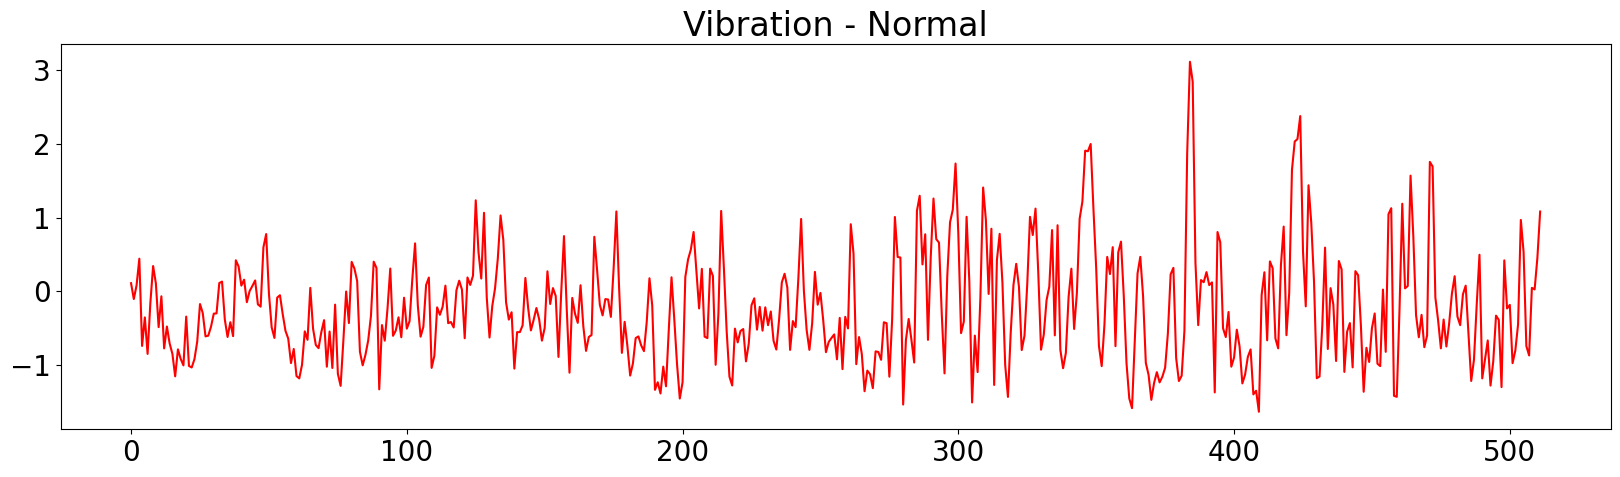

In [25]:
plt.figure(figsize=(20,5))
plt.title("Vibration - Normal")
plt.plot(vib_train_ds[0], color="red")
plt.show()

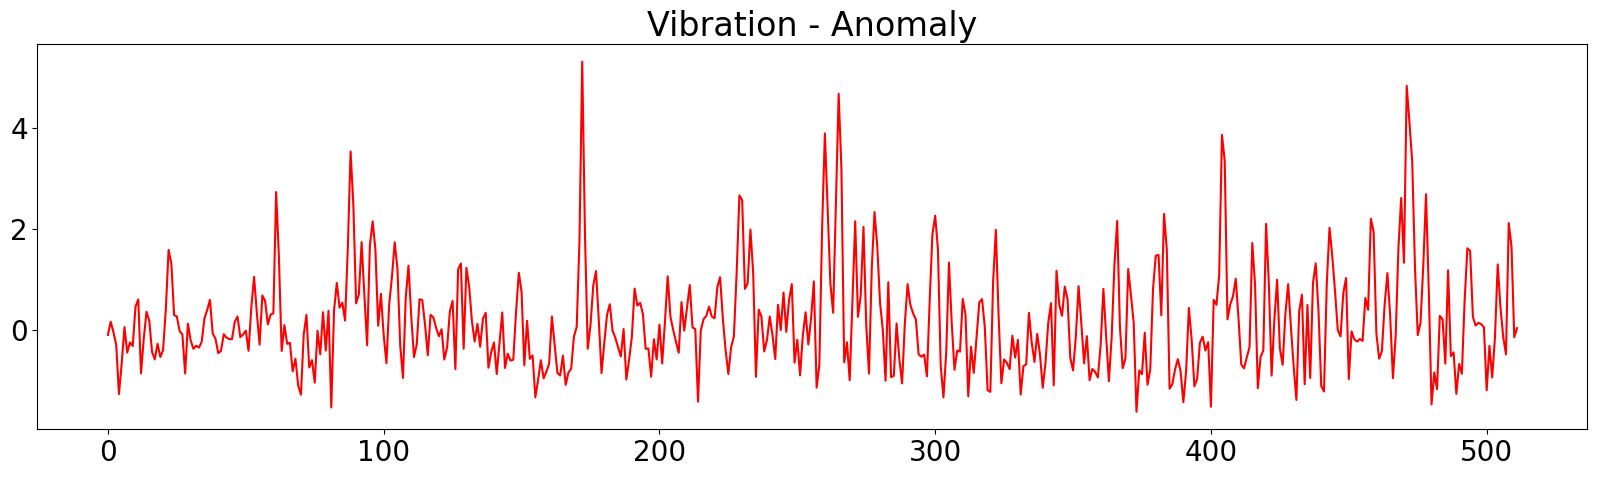

In [26]:
plt.figure(figsize=(20,5))
plt.title("Vibration - Anomaly")
plt.plot(vib_train_ds[-1], color="red")
plt.show()

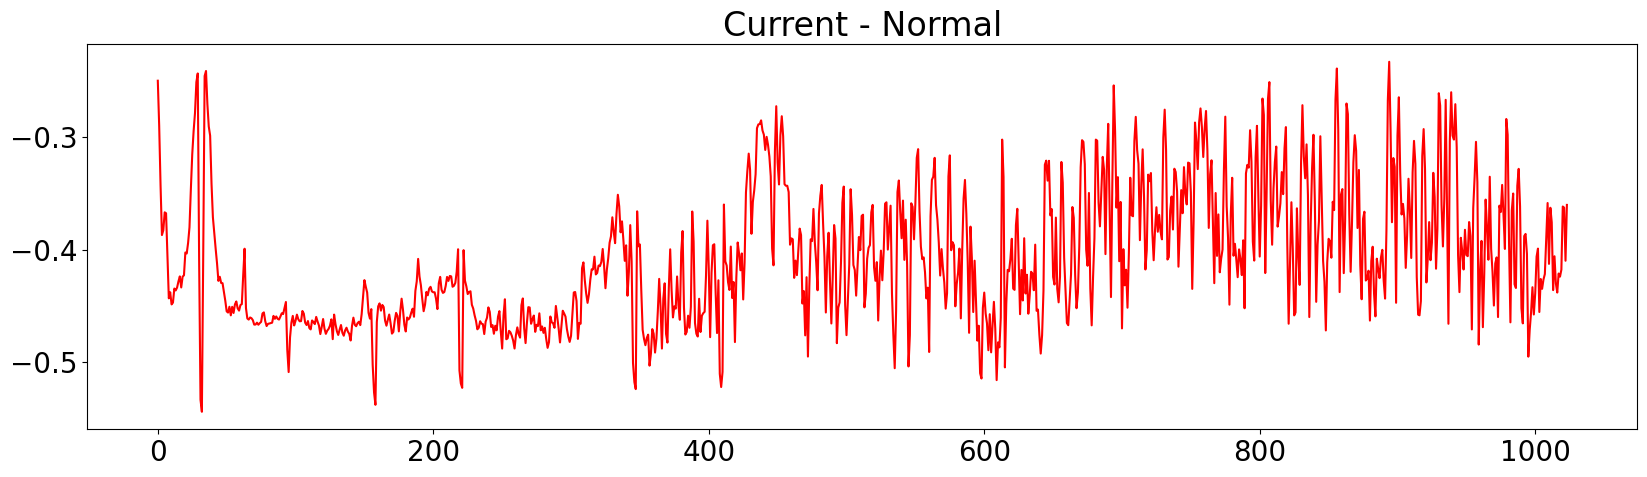

In [27]:
plt.figure(figsize=(20,5))
plt.title("Current - Normal")
plt.plot(cur_test_ds[0], color="red")
plt.show()

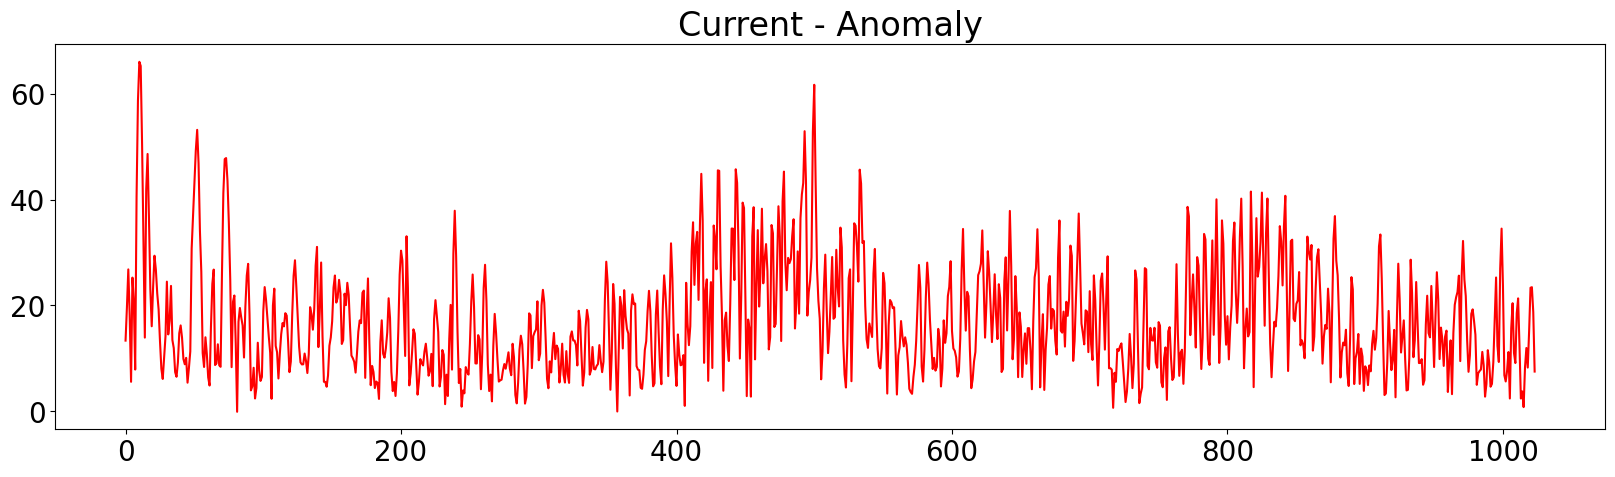

In [28]:
plt.figure(figsize=(20,5))
plt.title("Current - Anomaly")
plt.plot(cur_test_ds[-1], color="red")
plt.show()

In [29]:
type(vib_train_ds)

numpy.ndarray

In [30]:
type(cur_train_ds)

numpy.ndarray

In [31]:
type(vib_test_ds)

numpy.ndarray

In [32]:
type(cur_test_ds)

numpy.ndarray

In [33]:
vib_train_ds.shape

(1758, 512)

In [34]:
vib_test_ds.shape

(32, 512)

In [35]:
cur_train_ds.shape

(8170, 1024)

In [36]:
cur_test_ds.shape

(64, 1024)

In [37]:
type(vib_train_ds.shape)

tuple

In [38]:
vib_train_ds.shape[0]

1758

In [39]:
vib_train_ds.shape[1]

512

In [40]:
vib_train_ds = vib_train_ds.reshape(vib_train_ds.shape[0], vib_train_ds.shape[1],1)
vib_test_ds = vib_test_ds.reshape(vib_test_ds.shape[0], vib_test_ds.shape[1],1)
cur_train_ds = cur_train_ds.reshape(cur_train_ds.shape[0], cur_train_ds.shape[1], 1)
cur_test_ds = cur_test_ds.reshape(cur_test_ds.shape[0], cur_test_ds.shape[1], 1)

print("진동 학습데이터 shape:", vib_train_ds.shape)
print("진동 평가데이터 shape:", vib_test_ds.shape)
print("전류 학습데이터 shape:", cur_train_ds.shape)
print("전류 평가데이터 shape:", cur_test_ds.shape)

진동 학습데이터 shape: (1758, 512, 1)
진동 평가데이터 shape: (32, 512, 1)
전류 학습데이터 shape: (8170, 1024, 1)
전류 평가데이터 shape: (64, 1024, 1)


In [41]:
def Conv_AE(input_ds):
    model = Sequential()
    model.add(Input(shape=(input_ds.shape[1], input_ds.shape[2])))
    model.add(Conv1D(filters=64, kernel_size=input_ds.shape[1]//64, padding="same", strides=2, activation="relu"))
    model.add(Conv1D(filters=32, kernel_size=input_ds.shape[1]//64, padding="same", activation="relu"))
    model.add(Conv1DTranspose(filters=64, kernel_size=input_ds.shape[1]//64, padding="same", strides=2, activation="relu"))
    model.add(Conv1DTranspose(filters=1, kernel_size=input_ds.shape[1]//64, padding="same"))

    return model

In [42]:
vib_model=Conv_AE(vib_train_ds)
vib_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 256, 64)        │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 32)        │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 512, 64)        │        16,448 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 512, 1)         │           513 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
cur_model=Conv_AE(cur_train_ds)
cur_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 512, 64)        │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 512, 32)        │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 1024, 64)       │        32,832 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_3              │ (None, 1024, 1)        │         1,025 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,745 (264.63 KB)

 Trainable params: 67,745 (264.63 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
vib_model.compile(loss="mae", optimizer="adam")
vib_history = vib_model.fit(x=vib_train_ds, y=vib_train_ds, epochs=100, validation_split=0.2, callbacks=[EarlyStopping(monitor="val_loss", patience=10)])

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2589 - val_loss: 0.0714
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0493 - val_loss: 0.0438
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0387 - val_loss: 0.0404
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0330 - val_loss: 0.0314
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0293 - val_loss: 0.0326
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0309 - val_loss: 0.0298
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0293 - val_loss: 0.0248
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0285 - val_loss: 0.0268
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0290 - val_loss: 0.0320
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0255 - val_loss: 0.0237
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0258 - val_loss: 0.0207
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

In [45]:
cur_model.compile(loss="mae", optimizer="adam")
cur_history = cur_model.fit(x=vib_train_ds, y=vib_train_ds, epochs=100, validation_split=0.2, callbacks=[EarlyStopping(monitor="val_loss", patience=10)])

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.2574 - val_loss: 0.1013
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0715 - val_loss: 0.0590
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0546 - val_loss: 0.0597
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0671 - val_loss: 0.0547
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0445 - val_loss: 0.0459
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0461 - val_loss: 0.0446
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0406 - val_loss: 0.0454
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0490 - val_loss: 0.0795
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0452 - val_loss: 0.0488
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0346 - val_loss: 0.0347
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0358 - val_loss: 0.0326
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

In [46]:
vib_history.history["loss"]

[0.2589185833930969,
 0.04931018128991127,
 0.038671061396598816,
 0.03296321630477905,
 0.02925165742635727,
 0.030933260917663574,
 0.029312632977962494,
 0.02847447618842125,
 0.02902393601834774,
 0.025484375655651093,
 0.02584546059370041,
 0.023903172463178635,
 0.041105326265096664,
 0.028003215789794922,
 0.023828430101275444,
 0.028315691277384758,
 0.026939455419778824,
 0.0241338312625885,
 0.020339978858828545,
 0.020527193322777748,
 0.019669385626912117,
 0.026529159396886826,
 0.021667134016752243,
 0.02487439475953579,
 0.03018948622047901,
 0.027472559362649918,
 0.01973661780357361,
 0.039876628667116165]

In [47]:
vib_history.history["val_loss"]

[0.07140984386205673,
 0.043788693845272064,
 0.04036634787917137,
 0.03140852972865105,
 0.03259249031543732,
 0.029781503602862358,
 0.02478247880935669,
 0.02683386020362377,
 0.03203834220767021,
 0.023677926510572433,
 0.02066916972398758,
 0.024806492030620575,
 0.03109806776046753,
 0.038401201367378235,
 0.022599151358008385,
 0.03953247889876366,
 0.027787143364548683,
 0.017304250970482826,
 0.020334187895059586,
 0.018472351133823395,
 0.02599518373608589,
 0.026590071618556976,
 0.02455100603401661,
 0.02501078136265278,
 0.03286302462220192,
 0.02502010017633438,
 0.08269774913787842,
 0.02434469945728779]

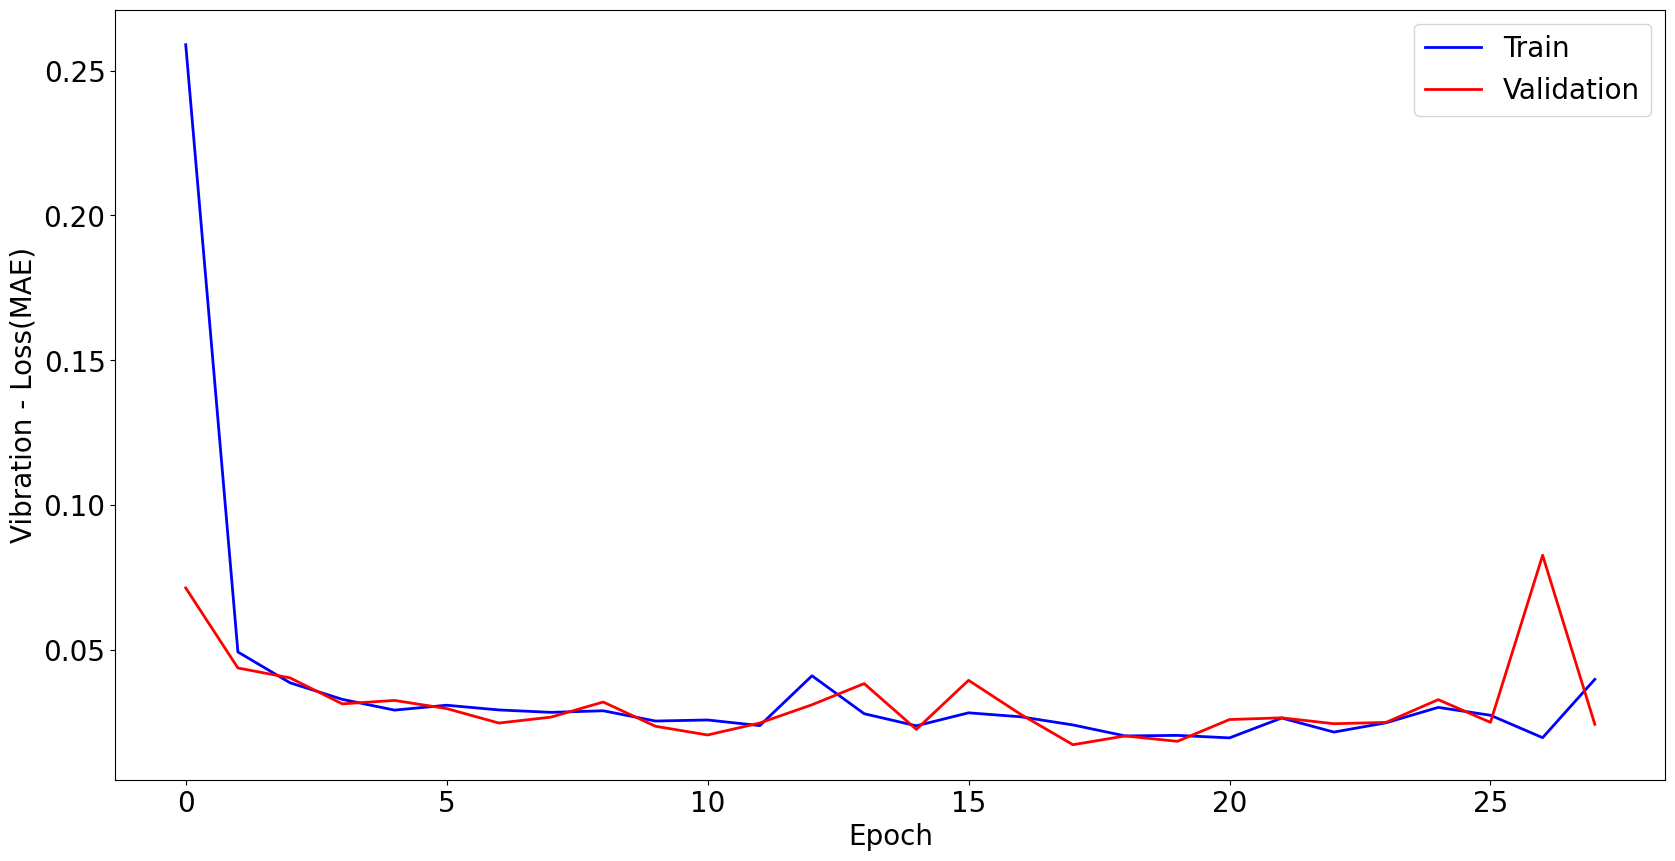

In [48]:
plt.figure(figsize=(20, 10))
plt.plot(vib_history.history["loss"], color="blue", label="Train", linewidth=2)
plt.plot(vib_history.history["val_loss"], color="red", label="Validation", linewidth=2)
plt.ylabel("Vibration - Loss(MAE)")
plt.xlabel("Epoch")
plt.legend()
plt.show()

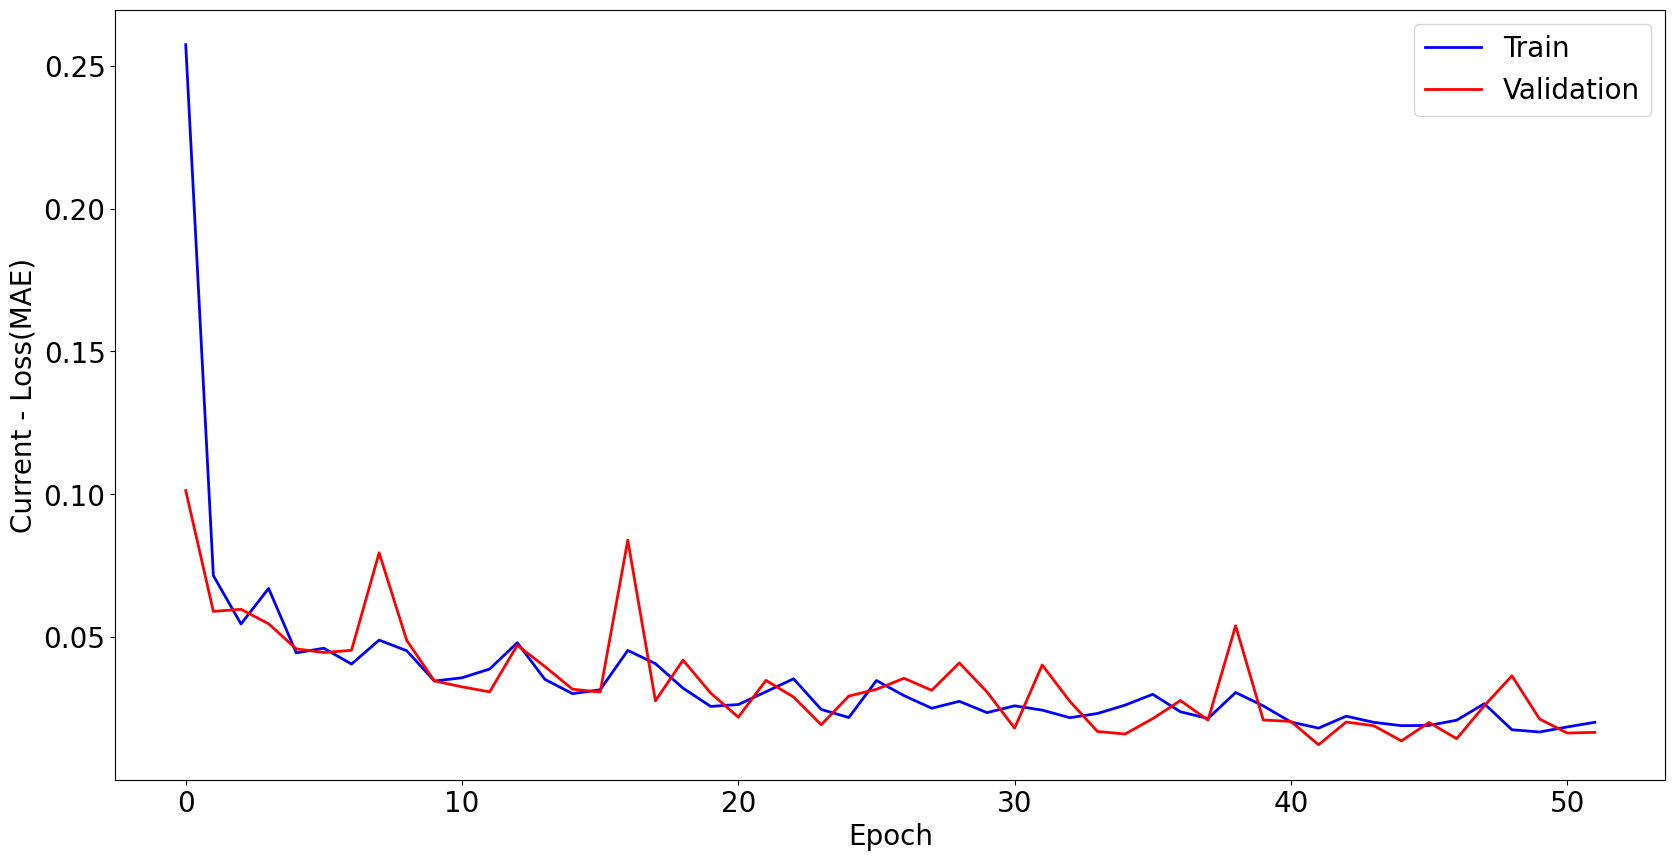

In [49]:
plt.figure(figsize=(20, 10))
plt.plot(cur_history.history["loss"], color="blue", label="Train", linewidth=2)
plt.plot(cur_history.history["val_loss"], color="red", label="Validation", linewidth=2)
plt.ylabel("Current - Loss(MAE)")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [50]:
vib_yhat = vib_model.predict(vib_train_ds)
vib_yhat.shape

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


(1758, 512, 1)

In [51]:
cur_yhat = cur_model.predict(cur_train_ds)
cur_yhat.shape

256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


(8170, 1024, 1)

d:\venv\venvPython1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\venv\venvPython1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


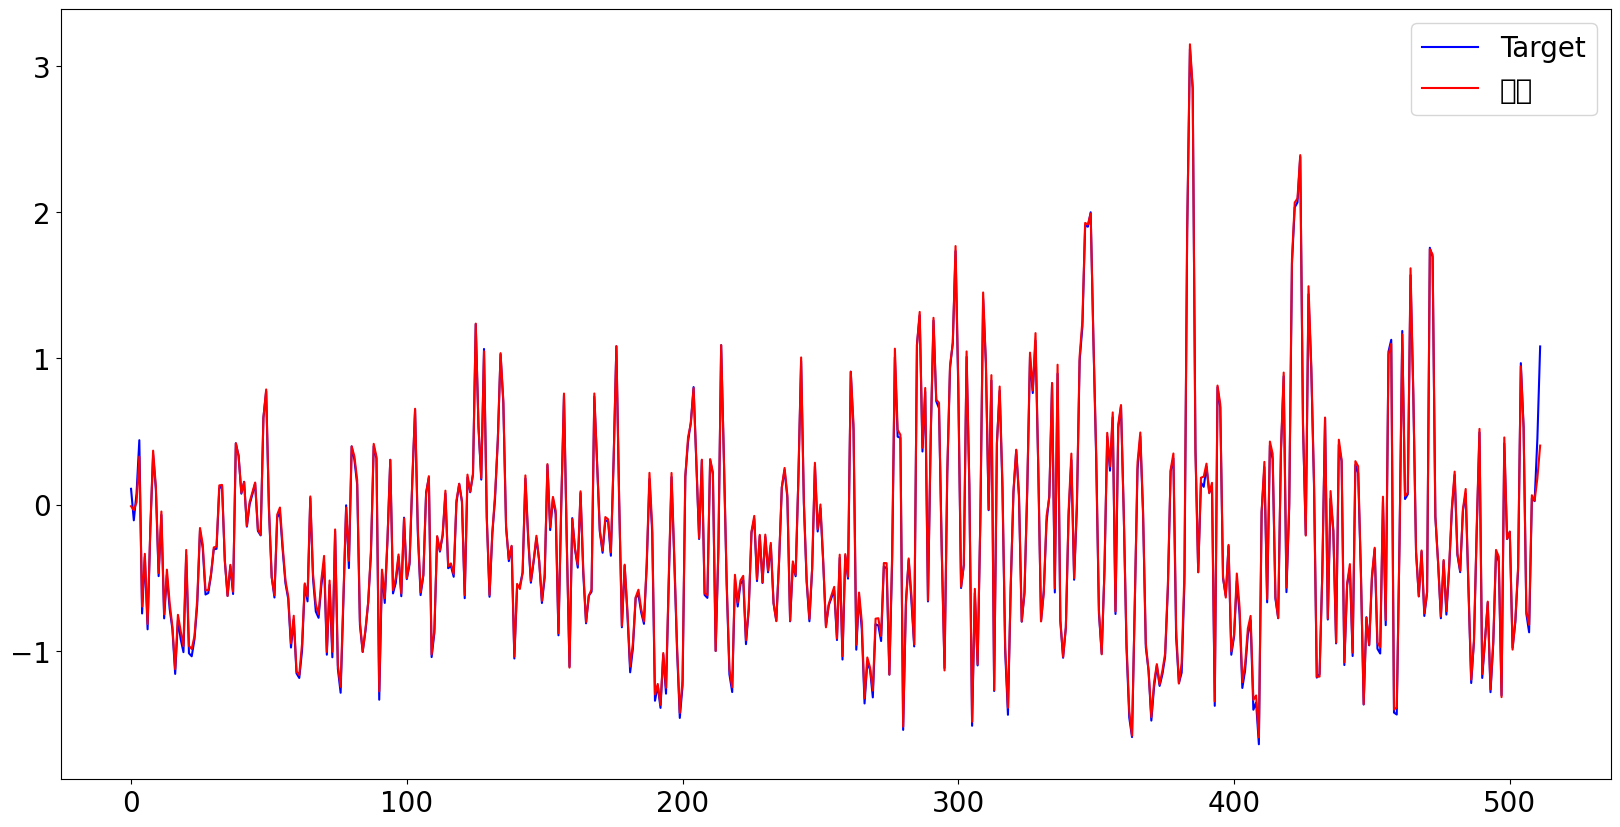

In [52]:
plt.figure(figsize=(20, 10))
plt.plot(vib_train_ds[0], color="blue", label="Target")
plt.plot(vib_yhat[0], color="red", label="복원")
plt.legend()
plt.show()

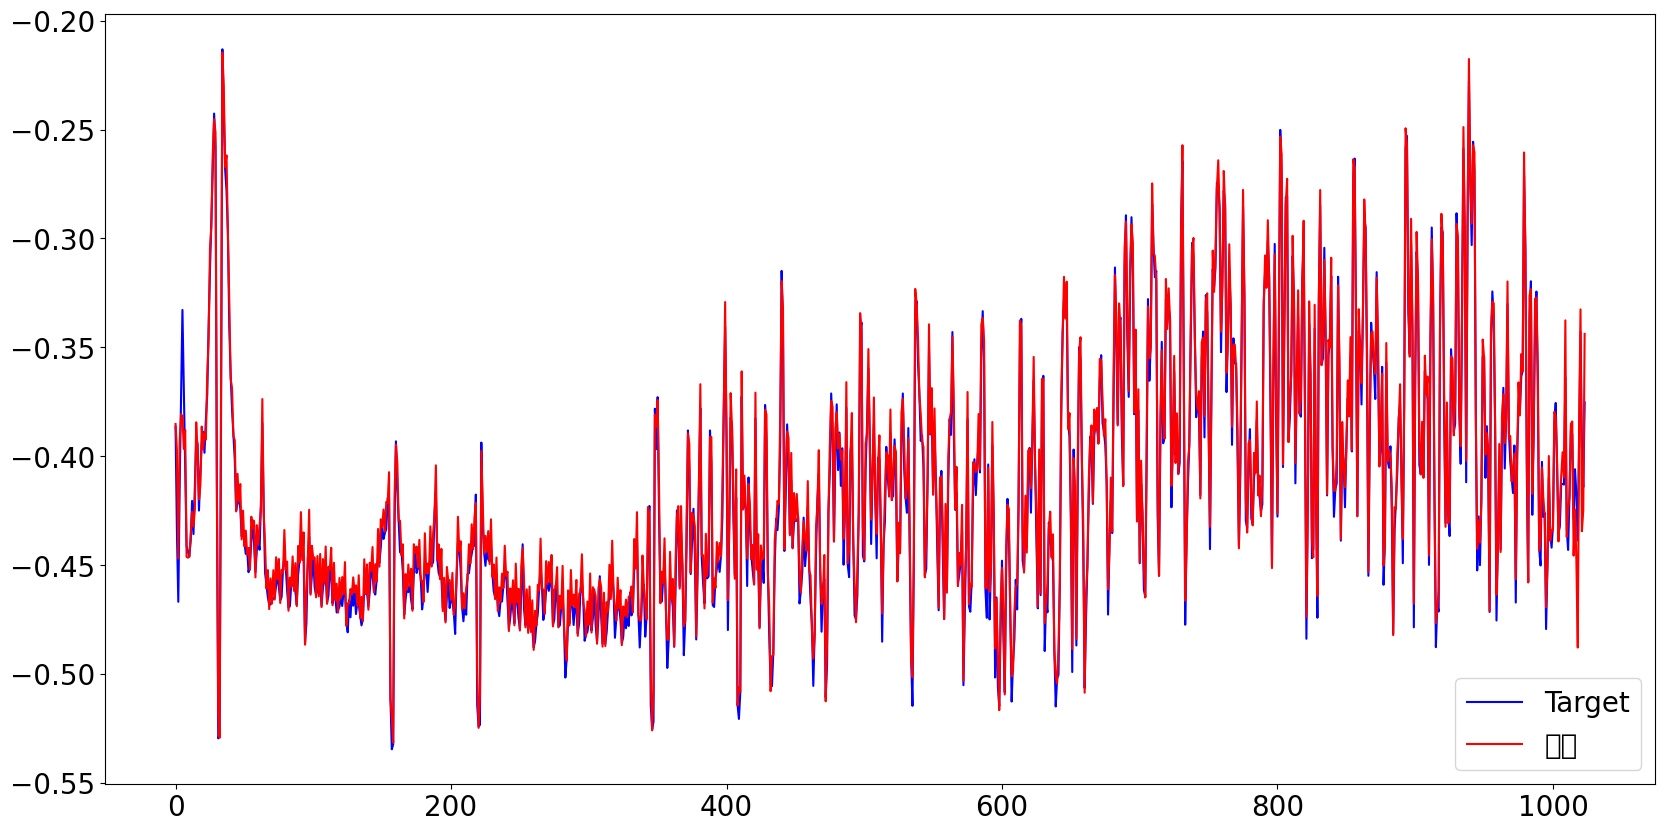

In [53]:
plt.figure(figsize=(20, 10))
plt.plot(cur_train_ds[0], color="blue", label="Target")
plt.plot(cur_yhat[0], color="red", label="복원")
plt.legend()
plt.show()

In [54]:
vib_mae = np.mean(np.abs(vib_yhat - vib_train_ds), axis=1)
vib_mae

array([[0.0221059 ],
       [0.01927919],
       [0.02217258],
       ...,
       [0.02429564],
       [0.02257559],
       [0.02253178]])

In [55]:
cur_mae = np.mean(np.abs(cur_yhat - cur_train_ds), axis=1)
cur_mae

array([[0.00687261],
       [0.0068786 ],
       [0.00670026],
       ...,
       [0.00673622],
       [0.00677325],
       [0.00689691]])

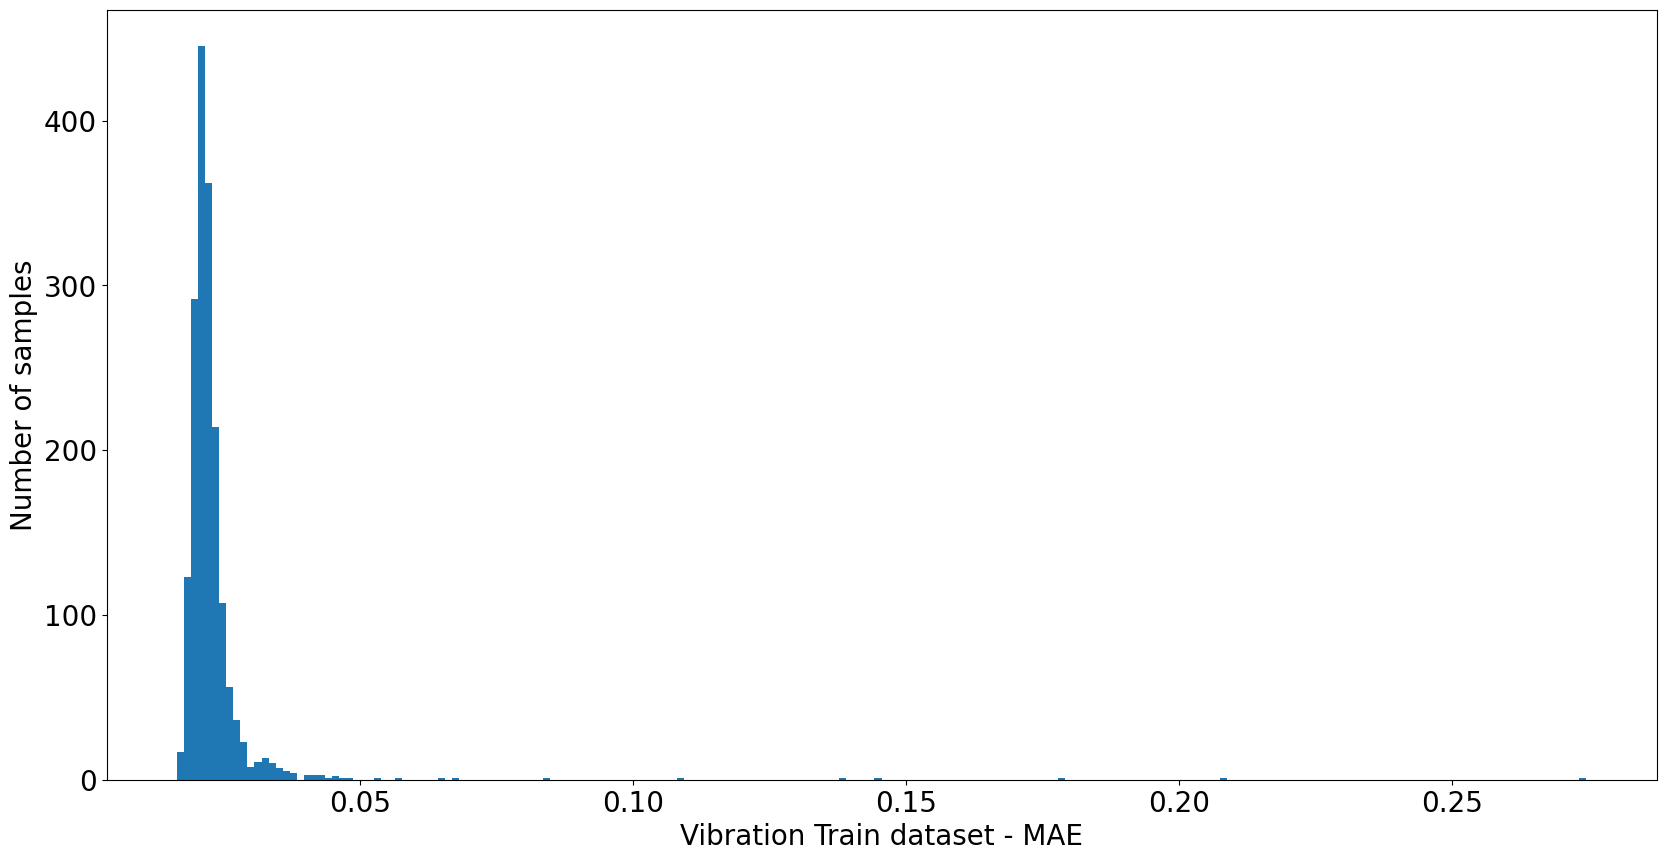

In [56]:
plt.figure(figsize=(20,10))
plt.hist(x=vib_mae, bins=200)
plt.xlabel("Vibration Train dataset - MAE")
plt.ylabel("Number of samples")
plt.show()

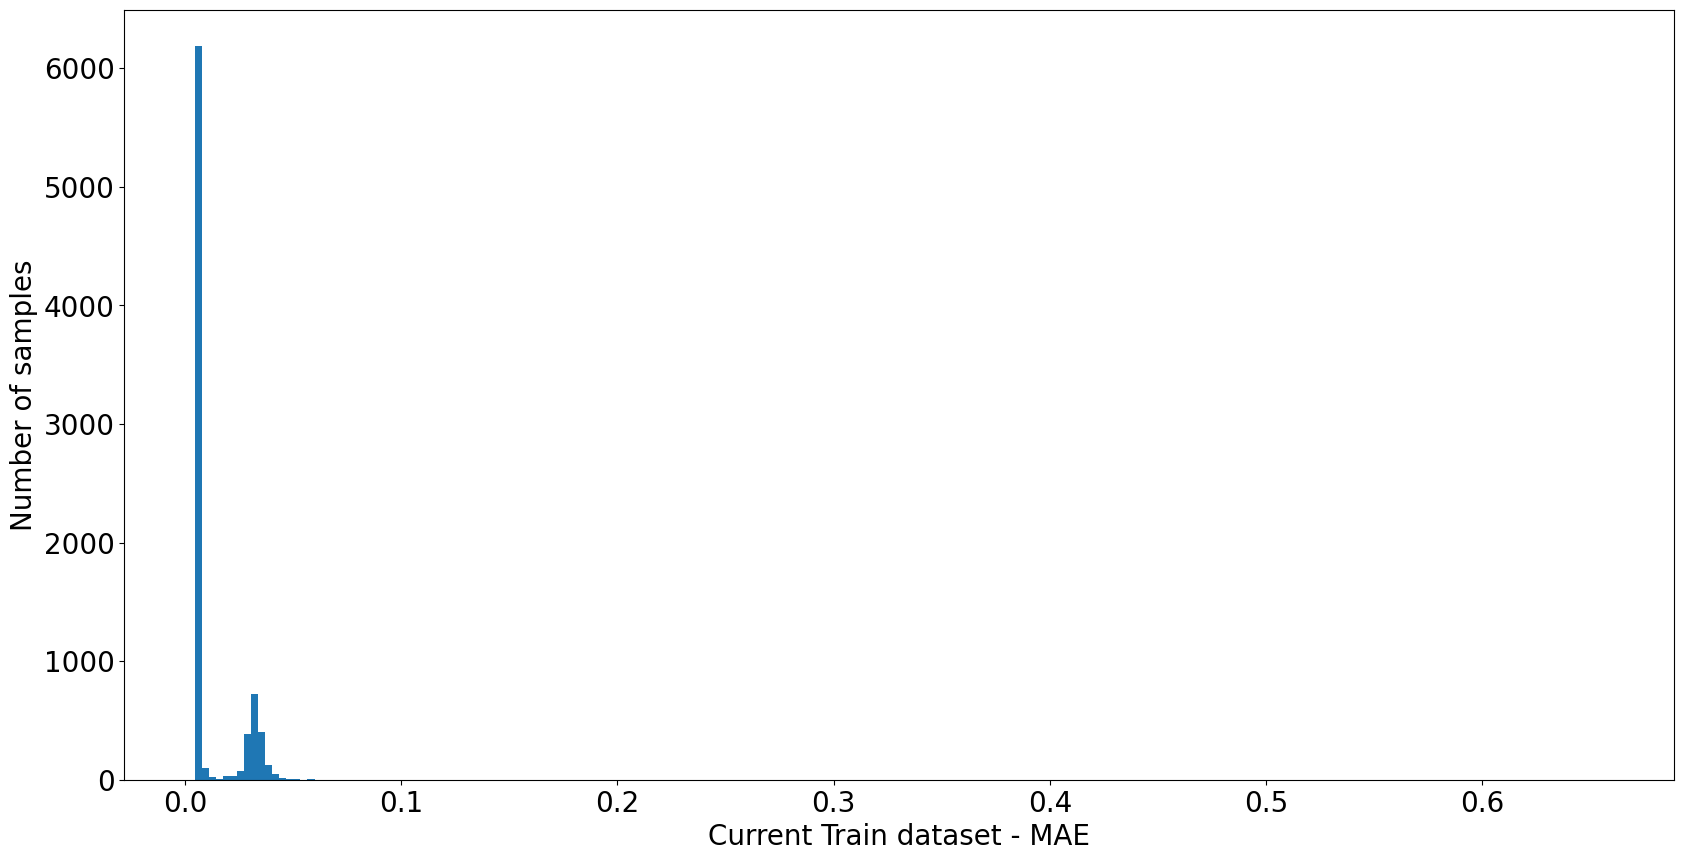

In [57]:
plt.figure(figsize=(20,10))
plt.hist(x=cur_mae, bins=200)
plt.xlabel("Current Train dataset - MAE")
plt.ylabel("Number of samples")
plt.show()

In [58]:
vib_threshold = np.mean(vib_mae) + 3*np.std(vib_mae)
cur_threshold = np.mean(cur_mae) + 3*np.std(cur_mae)

print("진동 데이터 임계치:", vib_threshold)
print("전류 데이터 임계치:", cur_threshold)

진동 데이터 임계치: 0.05405860490896536
전류 데이터 임계치: 0.05525359492575035


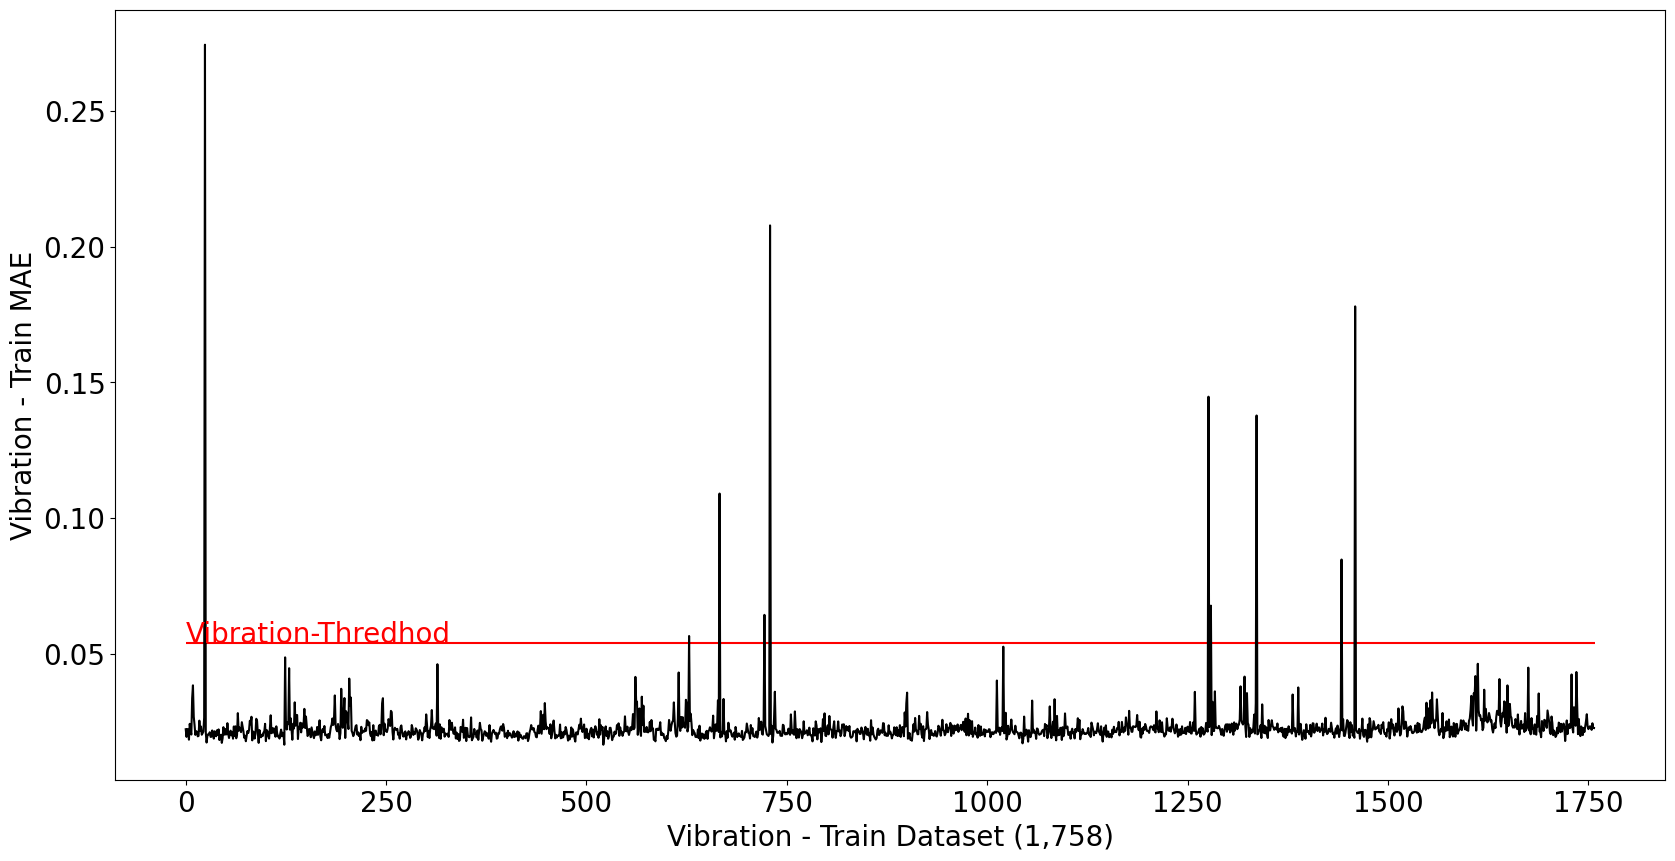

In [59]:
plt.figure(figsize=(20,10))
plt.text(x=0, y=vib_threshold, s="Vibration-Thredhod", fontsize=20, color="red")
plt.hlines(y=vib_threshold, xmin=0, xmax=len(vib_mae), color="red", linestyle="-")
plt.xlabel("Vibration - Train Dataset (1,758)")
plt.ylabel("Vibration - Train MAE")
plt.plot(vib_mae, color="black")
plt.show()

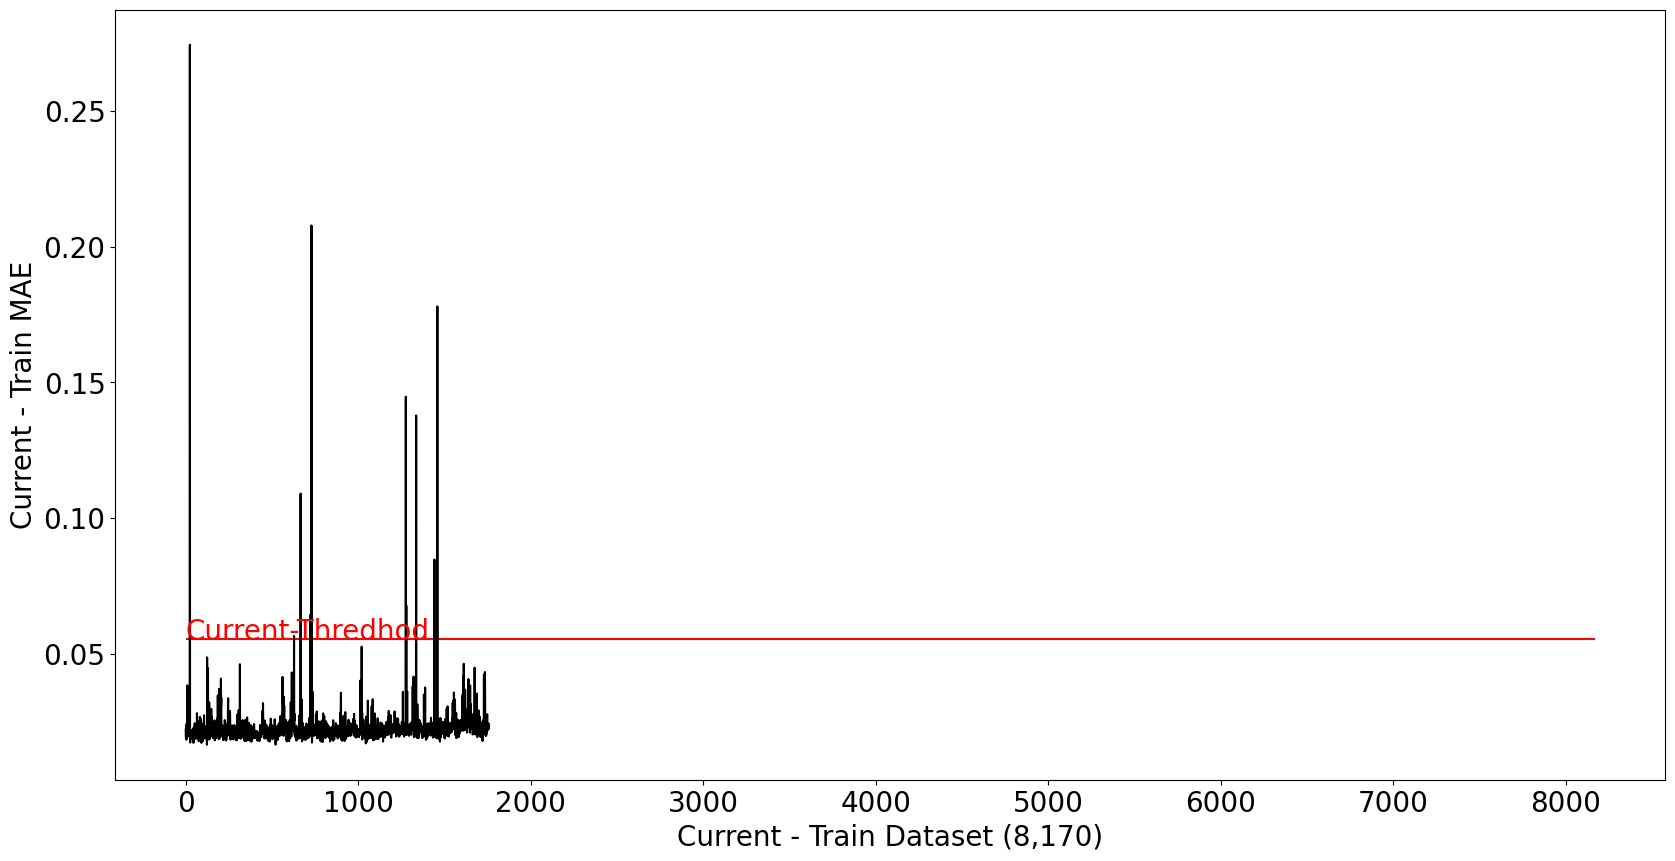

In [60]:
plt.figure(figsize=(20,10))
plt.text(x=0, y=cur_threshold, s="Current-Thredhod", fontsize=20, color="red")
plt.hlines(y=cur_threshold, xmin=0, xmax=len(cur_mae), color="red", linestyle="-")
plt.xlabel("Current - Train Dataset (8,170)")
plt.ylabel("Current - Train MAE")
plt.plot(vib_mae, color="black")
plt.show()

In [61]:
vib_yhat_test = vib_model.predict(vib_test_ds)
vib_mae_test = np.mean(np.abs(vib_yhat_test - vib_test_ds), axis=1)
vib_mae_test.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


(32, 1)

In [62]:
cur_yhat_test = cur_model.predict(cur_test_ds)
cur_mae_test = np.mean(np.abs(cur_yhat_test - cur_test_ds), axis=1)
cur_mae_test.shape

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


(64, 1)

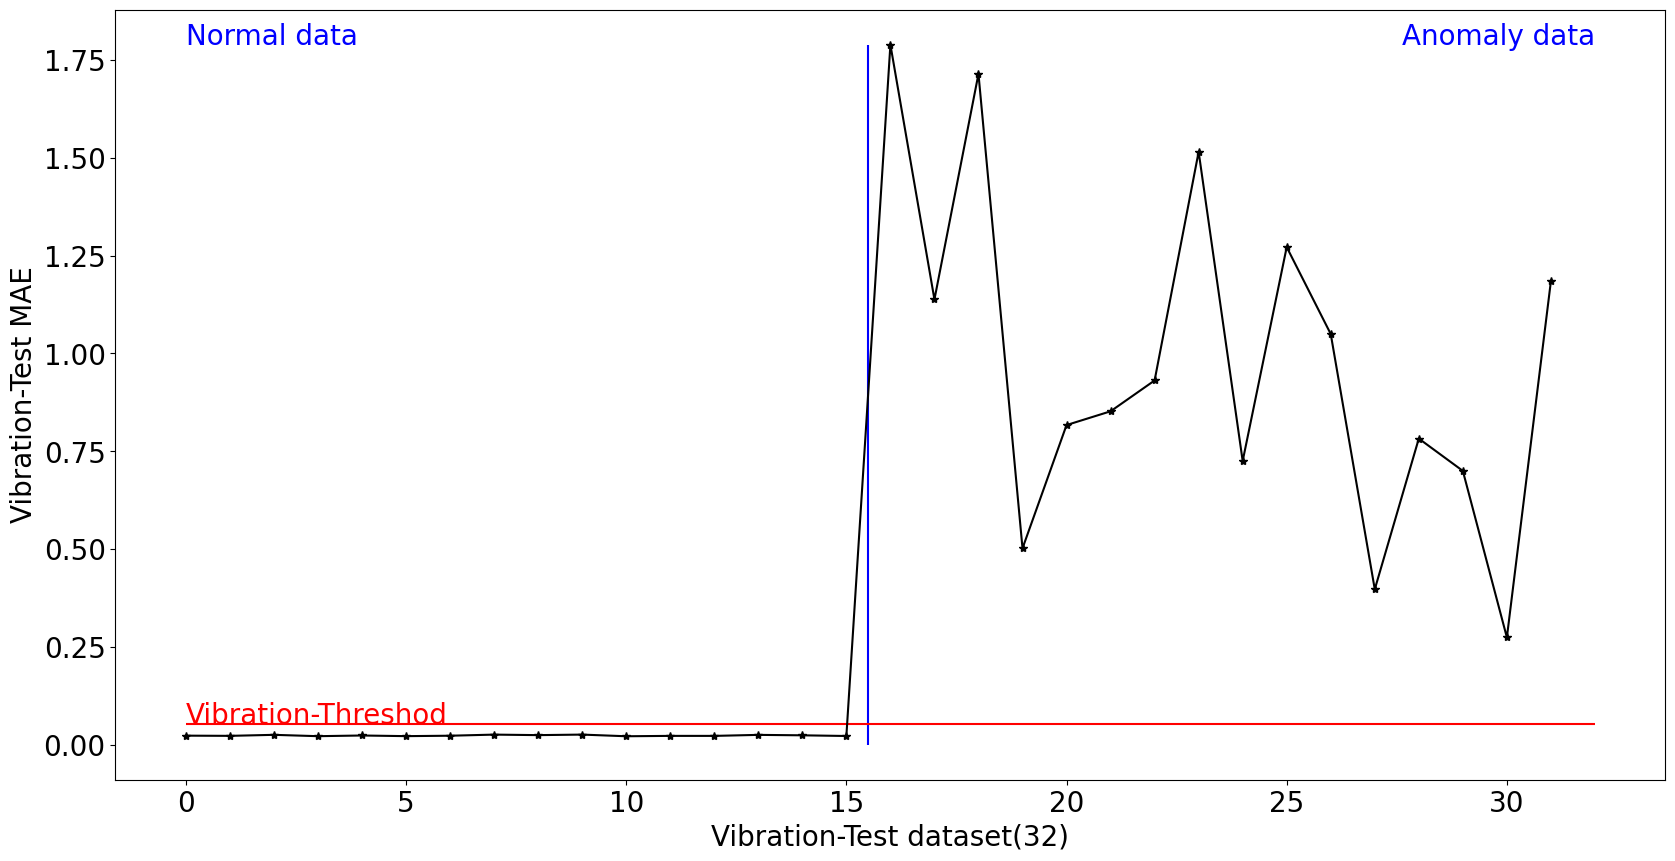

In [63]:
vib_mae_test = vib_mae_test.flatten()

plt.figure(figsize=(20,10))
plt.text(x=0, y=float(max(vib_mae_test)), s="Normal data", horizontalalignment="left", color="blue")
plt.text(x=32, y=float(max(vib_mae_test)), s="Anomaly data", horizontalalignment="right", color="blue")
plt.vlines(x=15.5, ymin=0, ymax=float(max(vib_mae_test)), color="blue", linestyle="-")
plt.text(x=0, y=float(vib_threshold), s="Vibration-Threshod", fontsize=20, color="red")
plt.hlines(y=float(vib_threshold), xmin=0, xmax=len(vib_mae_test), color="red", linestyle="-")
plt.xlabel("Vibration-Test dataset(32)")
plt.ylabel("Vibration-Test MAE")
plt.plot(vib_mae_test, color="black", marker="*")
plt.show()

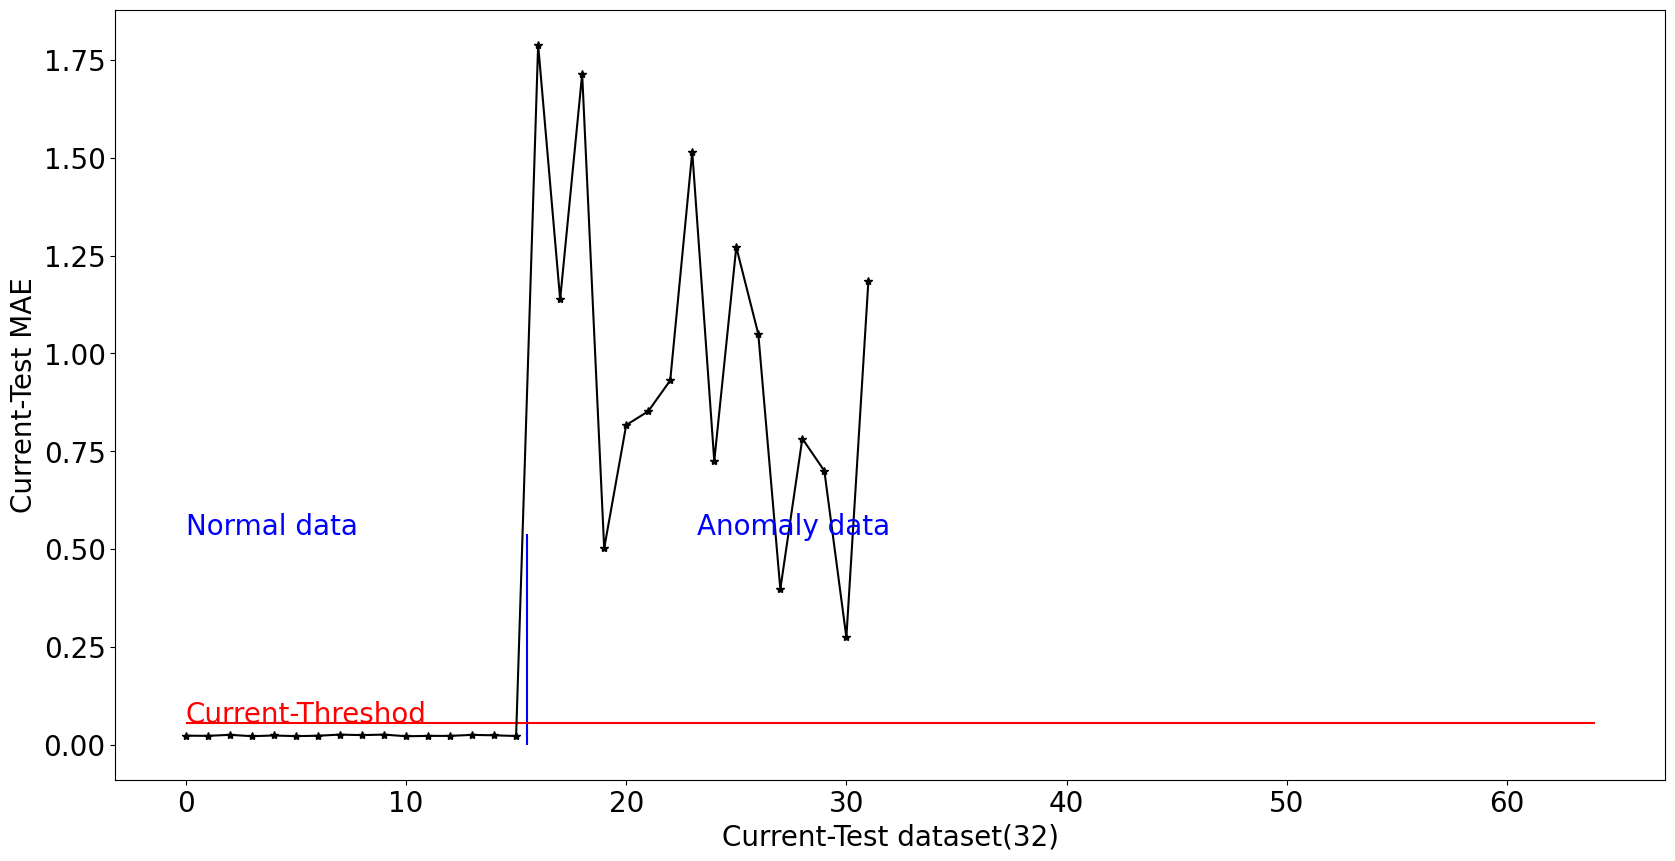

In [64]:
cur_mae_test = cur_mae_test.flatten()

plt.figure(figsize=(20,10))
plt.text(x=0, y=max(cur_mae_test), s="Normal data", horizontalalignment="left", color="blue")
plt.text(x=32, y=max(cur_mae_test), s="Anomaly data", horizontalalignment="right", color="blue")
plt.vlines(x=15.5, ymin=0, ymax=max(cur_mae_test), color="blue", linestyle="-")
plt.text(x=0, y=cur_threshold, s="Current-Threshod", fontsize=20, color="red")
plt.hlines(y=cur_threshold, xmin=0, xmax=len(cur_mae_test), color="red", linestyle="-")
plt.xlabel("Current-Test dataset(32)")
plt.ylabel("Current-Test MAE")
plt.plot(vib_mae_test, color="black", marker="*")
plt.show()